# 1. Persiapan
Mengimpor seluruh library yang digunakan selama proses pengolahan data, pembuatan model Deep Learning, evaluasi model, hyperparameter tuning menggunakan Optuna, dan pencatatan eksperimen menggunakan MLflow.

In [44]:
import sys
print(sys.version)

3.11.9 (tags/v3.11.9:de54cf5, Apr  2 2024, 10:12:12) [MSC v.1938 64 bit (AMD64)]


In [45]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

import optuna
import mlflow
import mlflow.tensorflow

# 2. Load Dataset
Tahap ini bertujuan memahami struktur dataset, jumlah fitur, tipe data, dan distribusi awal data sebelum dilakukan preprocessing.

In [46]:
df = pd.read_csv("midterm-regresi-dataset.csv")
df.head()
df.shape
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 515344 entries, 0 to 515343
Data columns (total 91 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   2001        515344 non-null  int64  
 1   49.94357    515344 non-null  float64
 2   21.47114    515344 non-null  float64
 3   73.0775     515344 non-null  float64
 4   8.74861     515344 non-null  float64
 5   -17.40628   515344 non-null  float64
 6   -13.09905   515344 non-null  float64
 7   -25.01202   515344 non-null  float64
 8   -12.23257   515344 non-null  float64
 9   7.83089     515344 non-null  float64
 10  -2.46783    515344 non-null  float64
 11  3.32136     515344 non-null  float64
 12  -2.31521    515344 non-null  float64
 13  10.20556    515344 non-null  float64
 14  611.10913   515344 non-null  float64
 15  951.0896    515344 non-null  float64
 16  698.11428   515344 non-null  float64
 17  408.98485   515344 non-null  float64
 18  383.70912   515344 non-null  float64
 19  32

,2001,49.94357,21.47114,73.0775,8.74861,-17.40628,-13.09905,-25.01202,-12.23257,7.83089,...,13.0162,-54.40548,58.99367,15.37344,1.11144,-23.08793,68.40795,-1.82223,-27.46348,2.26327
count,515344.000000,515344.000000,515344.000000,515344.000000,515344.000000,515344.000000,515344.000000,515344.000000,515344.000000,515344.000000,...,515344.000000,515344.000000,515344.000000,515344.000000,515344.000000,515344.000000,515344.000000,515344.000000,515344.000000,515344.000000
mean,1998.397077,43.387113,1.289515,8.658222,1.164110,-6.553580,-9.521968,-2.391046,-1.793215,3.727868,...,15.755411,-73.461537,41.542388,37.934163,0.315750,17.669292,-26.315520,4.458653,20.035229,1.329104
std,10.931056,6.067557,51.580393,35.268505,16.322802,22.860803,12.857763,14.571853,7.963822,10.582869,...,32.099666,175.619058,122.228915,95.050718,16.161780,114.428002,173.977455,13.346567,185.558415,22.088598
min,1922.000000,1.749000,-337.092500,-301.005060,-154.183580,-181.953370,-81.794290,-188.214000,-72.503850,-126.479040,...,-437.722030,-4402.376440,-1810.689190,-3098.350310,-341.789120,-3168.924570,-4319.992320,-236.039260,-7458.378150,-381.424430
25%,1994.000000,39.954667,-26.059848,-11.462775,-8.487507,-20.666455,-18.441005,-10.780360,-6.468390,-2.293670,...,-1.812658,-139.555737,-20.987115,-4.669655,-6.781598,-31.580617,-101.530305,-2.566137,-59.509453,-8.820248
50%,2002.000000,44.258490,8.417725,10.476235,-0.652855,-6.007770,-11.188355,-2.046625,-1.736415,3.822305,...,9.171850,-53.089115,28.790580,33.623815,0.820830,15.598520,-21.204225,3.117645,7.759910,0.053015
75%,2006.000000,47.833875,36.124030,29.764685,8.787548,7.741877,-2.388945,6.508587,2.913455,9.961865,...,26.274487,13.478793,89.661785,77.785810,8.471000,67.795110,52.389322,9.967742,86.351645,9.679540
max,2011.000000,61.970140,384.065730,322.851430,335.771820,262.068870,166.236890,172.402680,126.741270,146.297950,...,840.973380,4469.454870,3210.701700,1734.079690,260.544900,3662.065650,2833.608950,463.419500,7393.398440,677.899630


# 3. Cek Missing Value
Missing value dapat menyebabkan model tidak dapat belajar secara optimal sehingga perlu ditangani terlebih dahulu.

In [47]:
df.isnull().sum()
df.fillna(df.median(), inplace=True)

# 4. Pisahkan Feature dan Target
Kolom pertama merupakan label (tahun rilis lagu), sedangkan kolom lainnya merupakan fitur audio.

In [48]:
X = df.iloc[:,1:]
y = df.iloc[:,0]

# 5. Split 
Dataset dibagi menjadi data latih sebesar 80% dan data uji sebesar 20%.

In [49]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# 6. Standardisasi
Standardisasi dilakukan agar seluruh fitur memiliki skala yang sama sehingga proses pembelajaran neural network menjadi lebih stabil.

In [50]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 7. Membangun Model Deep Learning
Model menggunakan tiga hidden layer dengan fungsi aktivasi ReLU. Layer terakhir menggunakan satu neuron karena kasus yang dikerjakan adalah regresi.

In [51]:
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.2),

    Dense(32, activation='relu'),

    Dense(16, activation='relu'),

    Dense(1)
])

c:\Users\Fidela Risyunira\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [52]:
model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

# 8. Training
EarlyStopping digunakan agar proses training berhenti secara otomatis ketika model tidak lagi mengalami peningkatan performa sehingga dapat mengurangi overfitting.

In [53]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=30,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/30
10307/10307 ━━━━━━━━━━━━━━━━━━━━ 17s 2ms/step - loss: 119161.7188 - mae: 191.9173 - val_loss: 2765.7871 - val_mae: 43.7619
Epoch 2/30
10307/10307 ━━━━━━━━━━━━━━━━━━━━ 15s 1ms/step - loss: 4873.7695 - mae: 47.7318 - val_loss: 98.1021 - val_mae: 7.2310
Epoch 3/30
10307/10307 ━━━━━━━━━━━━━━━━━━━━ 16s 2ms/step - loss: 124.5727 - mae: 8.3167 - val_loss: 139.2784 - val_mae: 8.6871
Epoch 4/30
10307/10307 ━━━━━━━━━━━━━━━━━━━━ 17s 2ms/step - loss: 112.7789 - mae: 7.7046 - val_loss: 87.4102 - val_mae: 6.6920
Epoch 5/30
10307/10307 ━━━━━━━━━━━━━━━━━━━━ 19s 2ms/step - loss: 100.8464 - mae: 7.1924 - val_loss: 87.0767 - val_mae: 6.9821
Epoch 6/30
10307/10307 ━━━━━━━━━━━━━━━━━━━━ 15s 1ms/step - loss: 94.6547 - mae: 6.9907 - val_loss: 114.3530 - val_mae: 7.7570
Epoch 7/30
10307/10307 ━━━━━━━━━━━━━━━━━━━━ 13s 1ms/step - loss: 92.3525 - mae: 6.8779 - val_loss: 91.6268 - val_mae: 7.4224
Epoch 8/30
10307/10307 ━━━━━━━━━━━━━━━━━━━━ 13s 1ms/step - loss: 90.8850 - mae: 6.8156 - val_loss: 89.7957 -

# 9. Evaluasi
Empat metrik evaluasi digunakan sesuai ketentuan soal yaitu MSE, RMSE, MAE, dan R².

In [54]:
pred = model.predict(X_test)

mse = mean_squared_error(y_test,pred)

rmse = np.sqrt(mse)

mae = mean_absolute_error(y_test,pred)

r2 = r2_score(y_test,pred)

3221/3221 ━━━━━━━━━━━━━━━━━━━━ 2s 565us/step


# 10. Visualisasi Loss
Grafik ini digunakan untuk melihat apakah model mengalami overfitting atau underfitting selama proses pelatihan.

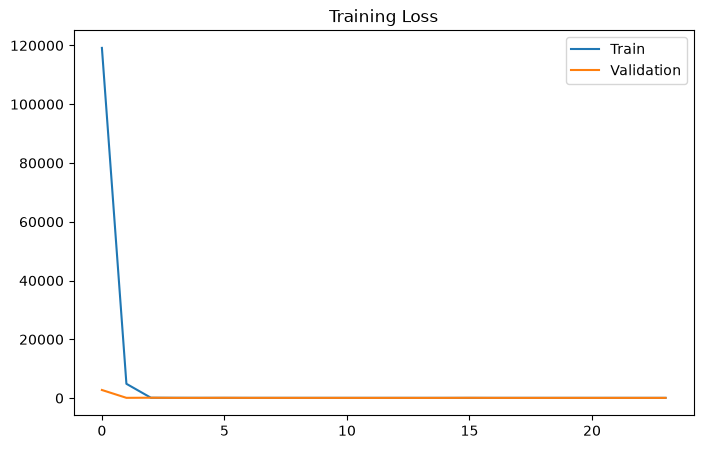

In [62]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.legend(['Train','Validation'])

plt.title("Training Loss")

plt.show()

# 11. Hyperparameter Tuning (Optuna)
Optuna digunakan untuk mencari kombinasi hyperparameter terbaik secara otomatis sehingga model memperoleh performa yang optimal.

In [56]:
def objective(trial):

    n1 = trial.suggest_int("layer1", 32, 128)
    n2 = trial.suggest_int("layer2", 16, 64)
    dropout = trial.suggest_float("dropout", 0.1, 0.4)

    model = Sequential([
        Dense(n1, activation='relu', input_shape=(X_train.shape[1],)),
        Dropout(dropout),

        Dense(n2, activation='relu'),

        Dense(1)
    ])

    model.compile(
        optimizer='adam',
        loss='mse'
    )

    history = model.fit(
        X_train,
        y_train,
        validation_split=0.2,
        epochs=5,
        verbose=0
    )

    return min(history.history['val_loss'])

In [57]:
study = optuna.create_study(direction="minimize")

study.optimize(objective,n_trials=5)

[I 2026-06-23 11:39:51,517] A new study created in memory with name: no-name-d6be29b7-dd3a-411c-94e7-29567699eb98
c:\Users\Fidela Risyunira\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
[I 2026-06-23 11:40:56,681] Trial 0 finished with value: 86.7349624633789 and parameters: {'layer1': 61, 'layer2': 56, 'dropout': 0.3526854464181085}. Best is trial 0 with value: 86.7349624633789.
[I 2026-06-23 11:42:03,723] Trial 1 finished with value: 98.9527359008789 and parameters: {'layer1': 63, 'layer2': 56, 'dropout': 0.16410584578540888}. Best is trial 0 with value: 86.7349624633789.
[I 2026-06-23 11:43:34,183] Trial 2 finished with value: 339.19708251953125 and parameters: {'layer1': 95, 'layer2'

# 12. MLflow
MLflow digunakan untuk menyimpan parameter, metrik evaluasi, dan model sehingga setiap eksperimen dapat dibandingkan dengan mudah.

In [58]:
import mlflow

mlflow.set_tracking_uri("sqlite:///mlflow.db")

mlflow.set_experiment("Deep Learning Regression")

<Experiment: artifact_location=('file:///c:/Users/Fidela Risyunira/Documents/PROJECT/UAS '
 'ML/finalterm-machine-learning/mlruns/1'), creation_time=1782188900425, effective_trace_archival_retention=None, experiment_id='1', last_update_time=1782188900425, lifecycle_stage='active', name='Deep Learning Regression', tags={}, trace_location=None, workspace='default'>

In [59]:
with mlflow.start_run():

    mlflow.log_param("optimizer", "adam")
    mlflow.log_param("epochs", 50)
    mlflow.log_param("batch_size", 32)

    mlflow.log_metric("MSE", mse)
    mlflow.log_metric("RMSE", rmse)
    mlflow.log_metric("MAE", mae)
    mlflow.log_metric("R2", r2)

    mlflow.tensorflow.log_model(
        model,
        "model"
    )

print("MLflow logging selesai")

2026/06/23 11:46:06 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/23 11:46:06 WARNING mlflow.tensorflow: You are saving a TensorFlow Core model or Keras model without a signature. Inference with mlflow.pyfunc.spark_udf() will not work unless the model's pyfunc representation accepts pandas DataFrames as inference inputs.


MLflow logging selesai
